   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

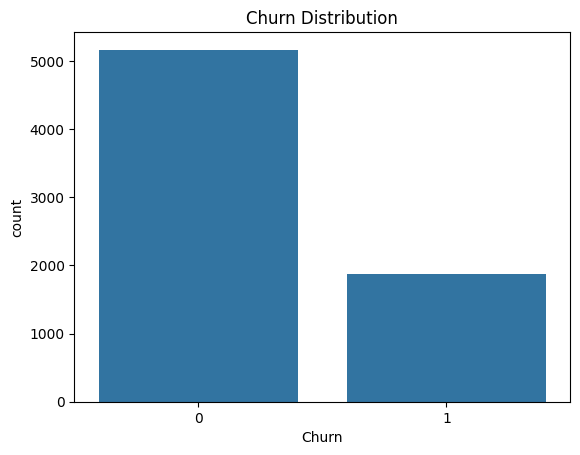

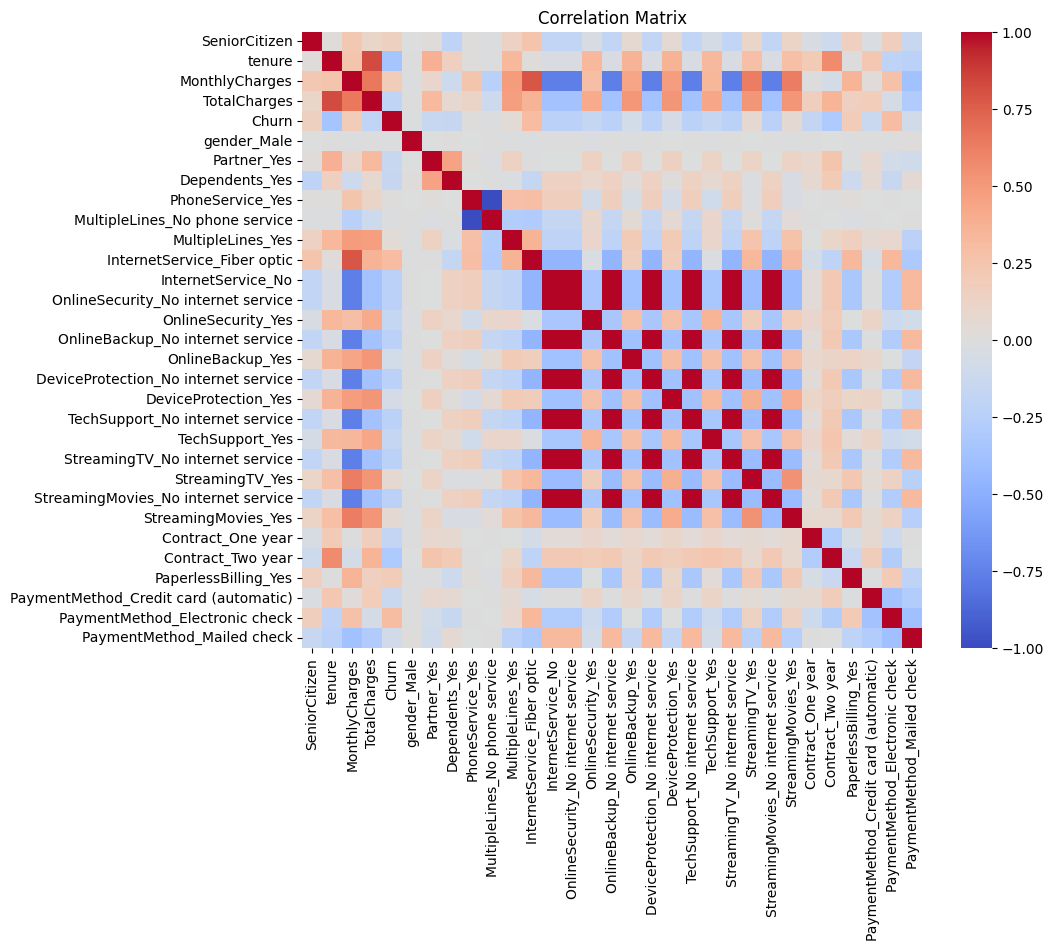

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8319235288940887
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

ROC-AUC: 0.8160205206785698
Best Params: {'max_depth': 10, 'n_estimators': 100}


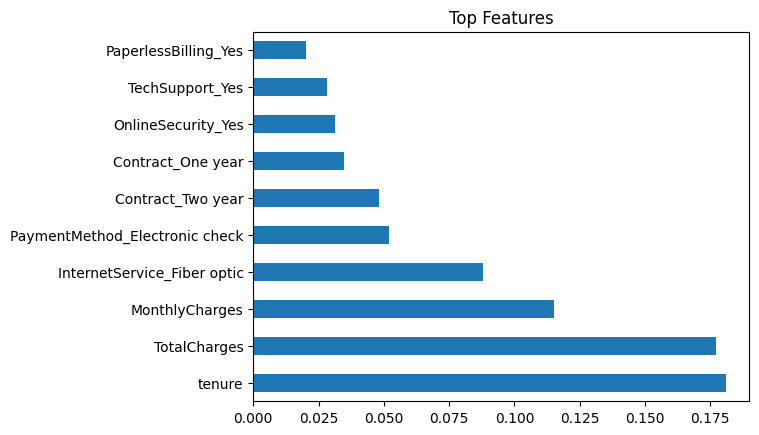


Top drivers of churn:
tenure                            0.180849
TotalCharges                      0.177109
MonthlyCharges                    0.115160
InternetService_Fiber optic       0.087887
PaymentMethod_Electronic check    0.052094
Contract_Two year                 0.047998
Contract_One year                 0.034604
OnlineSecurity_Yes                0.031230
TechSupport_Yes                   0.028215
PaperlessBilling_Yes              0.020279
dtype: float64

Insights:
- Clients with short tenure churn more
- Monthly charges strongly impact churn
- Contract type is critical

Business actions:
- Offer long-term contracts
- Target high-risk customers
- Improve customer experience



In [2]:
# 📊 TELCO CUSTOMER CHURN - COMPLETE NOTEBOOK

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())

# ==============================
# 3. DATA CLEANING
# ==============================
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(float)
df = df.dropna()

# ==============================
# 4. ENCODING
# ==============================
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df = df.drop("customerID", axis=1)
df = pd.get_dummies(df, drop_first=True)

# ==============================
# 5. EDA
# ==============================
plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 6. SPLIT DATA
# ==============================
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. SCALING
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 8. LOGISTIC REGRESSION
# ==============================
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

# ==============================
# 9. RANDOM FOREST
# ==============================
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# ==============================
# 10. HYPERPARAMETER TUNING (RF)
# ==============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Params:", grid.best_params_)

# ==============================
# 11. FEATURE IMPORTANCE
# ==============================
importances = best_rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.nlargest(10).plot(kind="barh")
plt.title("Top Features")
plt.show()

# ==============================
# 12. FINAL INTERPRETATION
# ==============================
print("\nTop drivers of churn:")
print(feat_imp.nlargest(10))

# ==============================
# 13. CONCLUSION
# ==============================
print("""
Insights:
- Clients with short tenure churn more
- Monthly charges strongly impact churn
- Contract type is critical

Business actions:
- Offer long-term contracts
- Target high-risk customers
- Improve customer experience
""")
